# Repaired reproducibility version

Derived from the original supplementary notebook. Original plotting/analysis cells are retained; only documented path, environment, missing-helper and unambiguous stale-variable fixes were applied. See `../REPAIR_LOG.md` for every change and items requiring manual confirmation.

In [1]:
source('../shared/r_funcs_repro.r')

# figure s8

- kernel: r_env, R 4.1.3
- date: 2024-0-22

## load

In [2]:
library(tidyverse)
library(logging)
library(ggpubr)
library(ggsci)
library(patchwork)
library(Seurat)

source('../shared/r_funcs_repro.r')

theme_set(theme_pubr())
logging::basicConfig()
options(warn = -1)

outdir <- '../../output/figs8'
create_dir(outdir)

── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ purrr     1.1.0
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [3]:
f_pat_gp <- '../../data/tables/patient_info_v2.tsv'
gp <- 'response'
gp_lvls$response <- c('R', 'NR')
gp_comp_map$response <- list(
  c('R-pre', 'R-post'),
  c('NR-pre', 'NR-post'),
  c('R-pre', 'NR-pre'),
  c('R-post', 'NR-post')
)
gp_comp_diff_map$response <- list(c('R', 'NR'))
gp_comp_map_pre$response <- list(c('R-pre', 'NR-pre'))
comb_order <- c('R-pre', 'R-post', 'NR-pre', 'NR-post')

## s8a: CD8_CXCL13 analysis

### delta expanded percent in subtype

min10 cells

In [4]:
f_expand_diff <- '../../data/figures/fig5/fig5a-expand_in_subtype-post_pre_delta.tsv'  # this is based on min10 cells results

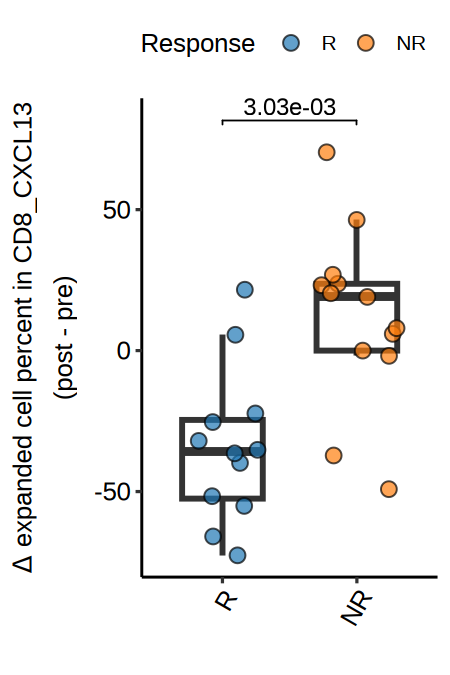

In [5]:
df_expand <- read_tsv(f_expand_diff, show_col_types = F) %>% 
    mutate(response = if_else(response == 'PR', 'NR', response)) %>%
    filter(subtype == 'CD8_CXCL13') %>%
    filter(!is.na(.data[[gp]]))
df_expand %>% write_tsv(str_glue('{outdir}/figs8a-expanded_pct_delta-CD8_CXCL13.tsv'))
p <- df_expand %>%
    cell_comp_boxplot(x = gp, y = 'pct_expand_diff', pt_fill = gp, pair_by = NULL, facet_by = NULL,
                      xorder = gp_lvls[[gp]], fill_order = gp_lvls[[gp]], xangle = 60) +
    labs(y = bquote(atop(Delta~'expanded cell percent in CD8_CXCL13', '(post - pre)')), fill = 'Response') +
    theme(legend.justification = c(1, 0))
p <- add_bh_wilcox(
    plot = p,
    comparisons = gp_comp_diff_map[[gp]],
    x = 'plot_x', y = 'pct_expand_diff', facet_by = NULL,
    stats_file = str_glue('{outdir}/figs8a-expand_diff-wilcoxon_bh.tsv')
)
ggsave(filename = str_glue('{outdir}/figs8a-box_expand_diff-CD8_CXCL13.pdf'), plot = p, width = 3, height = 4.5)
jp_opt(wd = 3, hg = 4.5)
print(p)


### shannon index

min 10 cells

In [6]:
f_diversity <- '../../data/stage4/a03_tcr/diversity/shannon_way2_min10.csv'

In [7]:
# process
df <- read_csv(f_diversity, show_col_types = F) %>%
    filter(subtype == 'CD8_CXCL13') %>%
    select(patient, sample_type, shannon) %>% 
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))

loginfo('%g samples for CD8_CXCL13', nrow(df))
df %>% write_tsv(str_glue('{outdir}/figs8a-diversity-CD8_CXCL13-min10.tsv'))

2026-07-18 18:11:27.619314 INFO::these clinial info will be added: response
2026-07-18 18:11:27.634188 INFO::76 samples for CD8_CXCL13


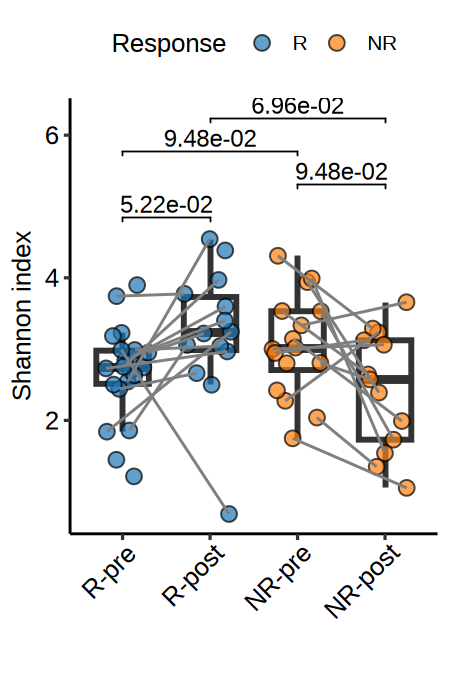

In [8]:
p <- read_tsv(str_glue('{outdir}/figs8a-diversity-CD8_CXCL13-min10.tsv'), show_col_types = F) %>% 
    filter(!is.na(.data[[gp]])) %>% 
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'shannon', pt_fill = gp, facet_by = NULL,
                      xorder = comb_order, fill_order = gp_lvls[[gp]], xangle = 45) +
    labs(y = 'Shannon index', fill = 'Response')
p <- add_bh_wilcox(
    plot = p,
    comparisons = gp_comp_map[[gp]],
    x = 'plot_x', y = 'shannon', facet_by = NULL,
    stats_file = str_glue('{outdir}/figs8a-diversity-wilcoxon_bh.tsv')
)
ggsave(filename = str_glue('{outdir}/figs8a-box_diversity-CD8_CXCL13.pdf'), plot = p, width = 3, height = 4.5)
jp_opt(wd = 3, hg = 4.5)
print(p)


## s8b: clone fraction: shared with CD8_CX3CR1 vs shared with non-CD8_CX3CR1

- sharing at sample level
- re-calculate clone fraction (based on RNA & TCR data)
- exclude CD8_CX3CR1 when plot

In [9]:
f_clone_info <- '../../data/stage4/a05_clone_share/clone_share_old/clone_sharing_info_per_cell.csv'
comp_ls <- list(
    c('CD8_CX3CR1_shared', 'otherT_shared'), 
    c('otherT_shared', 'specific'), 
    c('CD8_CX3CR1_shared', 'specific')
)
share_type_label_map <- c(
    'CD8_CX3CR1_shared' = 'shared with\nCD8_CX3CR1',
    'otherT_shared' = 'shared with\nnon-CD8_CX3CR1', 
    'specific' = 'unshared'
)

In [10]:
# Restored from the state definitions in figs7.ipynb
celltype_map <- list('T_MKI67' = c('T_Prolif'))
cell_state_map <- list(
    'cytotoxic' = c('CD8_ANXA1', 'CD8_CCL5', 'CD8_CX3CR1', 'CD8_FOS', 'CD8_GZMK', 'CD8_KLRB1'),
    'exhausted' = c('CD4_CXCL13', 'CD8_CXCL13', 'CD8_TYMS', 'T_MKI67', 'Treg_TNFRSF4'),
    'dying' = c('T_Mito'),
    'others' = c('CD4_KLRB1', 'CD8_CD74', 'CD8_IFIT1', 'T_IL7R', 'T_Ribo', 'Treg_LTB')
)

# re-calculate clone fraction
clone_frac <- read_csv(f_clone_info, show_col_types = F)  %>%
    add_count(sample, clonotype, name = 'n_cell_per_sample_clone') %>% 
    add_count(sample, name = 'n_cell_per_sample') %>% 
    select(sample, patient, sample_type, subtype, clonotype, share_type, n_cell_per_sample_clone, n_cell_per_sample) %>% 
    distinct() %>% 
    mutate(clone_frac_new = n_cell_per_sample_clone / n_cell_per_sample) %>%
    filter(subtype != 'CD8_CX3CR1') %>% # no CD8_CX3CR1
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))

# rename cell types
for (nm in names(celltype_map)) {
    clone_frac$subtype[clone_frac$subtype %in% celltype_map[[nm]]] <- nm
}
# add cell state info
clone_frac$cell_state <- 'unknown'
for (nm in names(cell_state_map)) {
    clone_frac$cell_state[clone_frac$subtype %in% cell_state_map[[nm]]] <- nm
}
clone_frac$cell_state[clone_frac$cell_state == 'cytotoxic'] <- 'other cytotoxic'

clone_frac %>% write_tsv(str_glue('{outdir}/figs8b-tcr_share_inter_subtype-clone_frac_new.tsv'), quote = 'needed')
loginfo('%g records of clonotypes in each sample, each subtype', nrow(clone_frac))

2026-07-18 18:12:04.477164 INFO::131179 records of clonotypes in each sample, each subtype


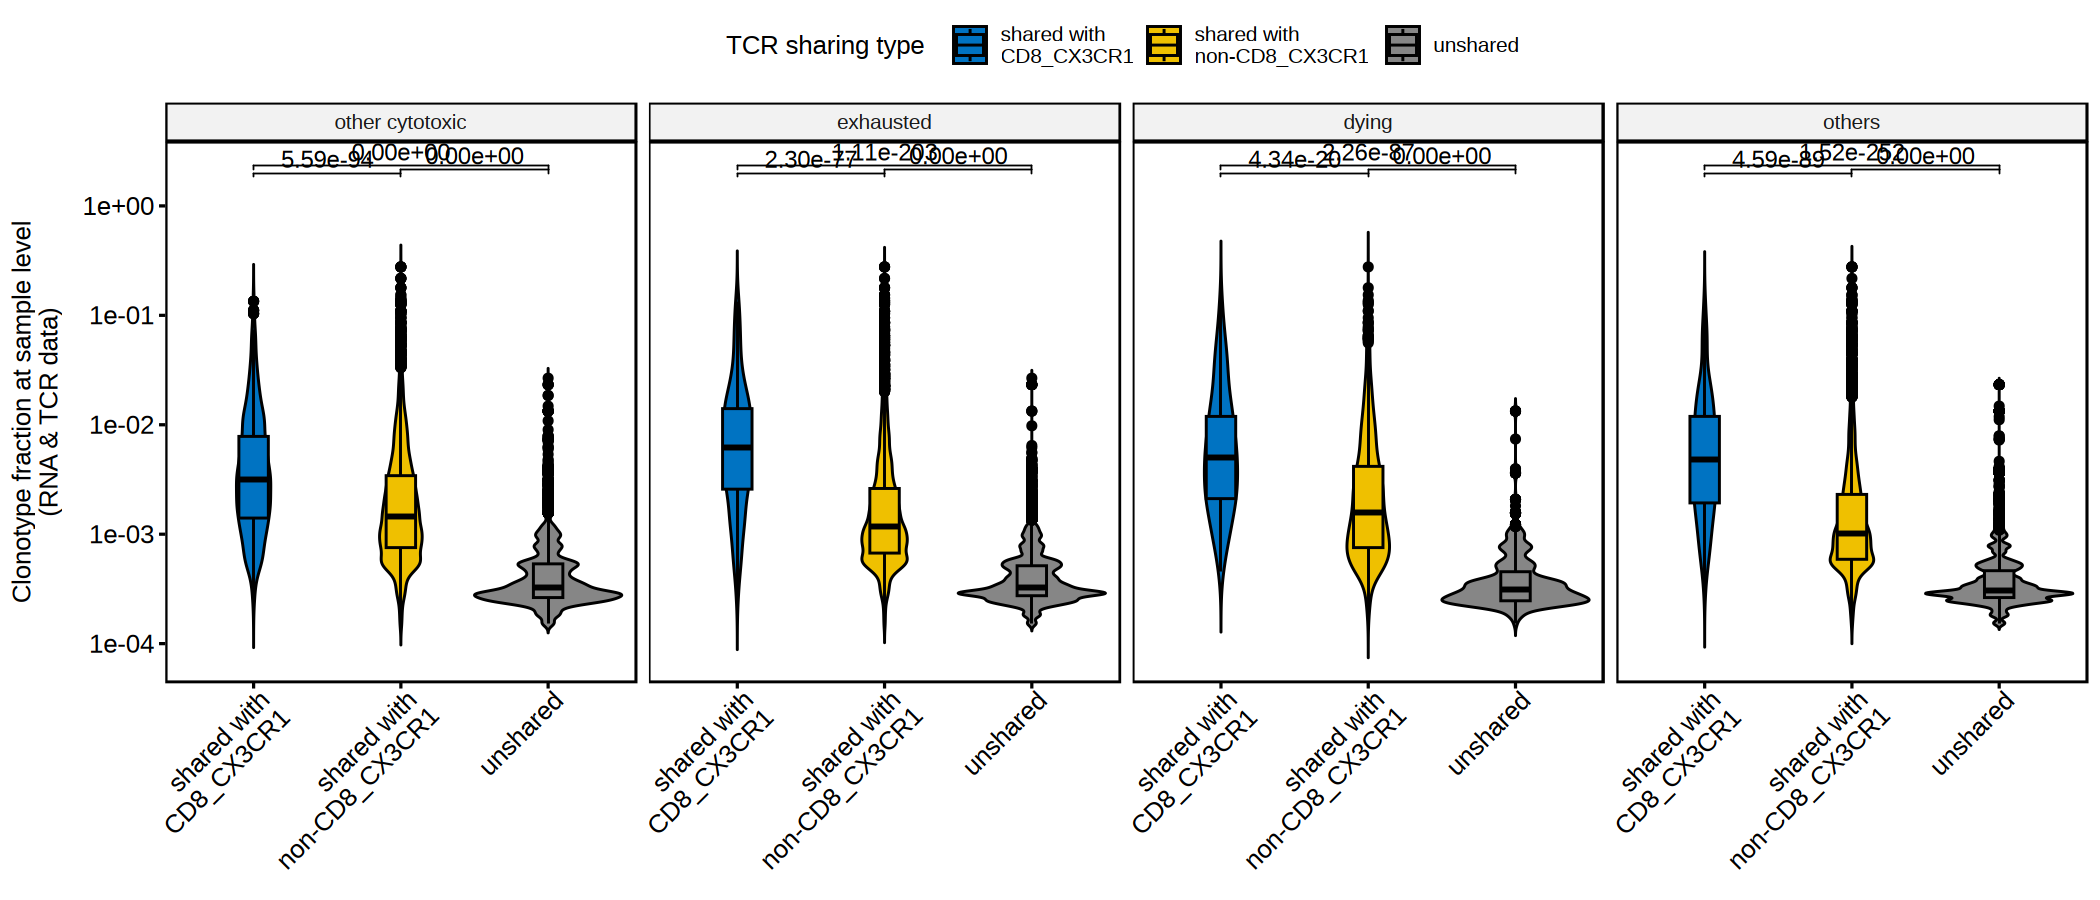

In [11]:
# plot
p <- read_tsv(str_glue('{outdir}/figs8b-tcr_share_inter_subtype-clone_frac_new.tsv'), show_col_types = F) %>% 
    mutate(cell_state = factor(cell_state, levels = c('other cytotoxic', 'exhausted', 'dying', 'others')),
           share_type = factor(share_type, levels = names(share_type_label_map))) %>%
    filter(!grepl('^NK', subtype)) %>%
    ggviolin(x = 'share_type', y = 'clone_frac_new', fill = 'share_type', 
             facet.by = 'cell_state', ncol = 9, add = 'boxplot') + 
    scale_fill_jco(breaks = names(share_type_label_map), labels = share_type_label_map) +
    scale_x_discrete(labels = share_type_label_map) +
    scale_y_continuous(trans = 'log10') +  # log10 won't influence wilcoxon test p value
    labs(y = 'Clonotype fraction at sample level\n(RNA & TCR data)', fill = 'TCR sharing type') +
    theme(axis.text.x = element_text(angle = 45, hjust = 0.95), axis.title.x = element_blank())
p <- add_bh_wilcox(
    plot = p,
    comparisons = comp_ls,
    x = 'share_type', y = 'clone_frac_new', facet_by = 'cell_state',
    stats_file = str_glue('{outdir}/figs8b-tcr_share-wilcoxon_bh.tsv')
)
ggsave(filename = str_glue('{outdir}/figs8b-vln_tcr_share_inter_subtype-clone_frac_new.pdf'), 
       plot = p, width = 14, height = 6)
jp_opt(wd = 14, hg = 6)
print(p)


## s8d: endo markers expression

In [12]:
f_obj <- '../../data/stage4/a01_data/seuobj/endo.rds'
markers <- list(
    'endo' = c('PECAM1', 'PLVAP'),
    'endo_vasc' = c('ICAM1', 'TEK'), 
    'endo_lymph' = c('LYVE1', 'PDPN', 'PROX1', 'FLT4'),
    'endo_inflam' = c('VWF', 'SELP', 'VCAM1', 'CX3CL1'),
    'junct' = c('CDH5'),
    'pericyte' = c('ACTA2', 'RGS5'),
    'endo_progen' = c('FLT1', 'KDR', 'MKI67'),
    'endoMT_transi' = c('DCN', 'COL1A1', 'COL1A2')
)

In [ ]:
scrna <- readRDS(f_obj)

In [ ]:
p <- DotPlot(scrna, feature = markers, group.by = 'cell_type') +
    RotatedAxis() +
    scale_color_gsea() +
    theme(axis.title = element_blank())
write_plot_source_data(p, str_glue('{outdir}/figs8d-dot_exprs-endo_markers-source_data.tsv'))
ggsave(filename = str_glue('{outdir}/figs8d-dot_exprs-endo_markers.pdf'),
       plot = p, width = 14, height = 6)
jp_opt(wd = 14, hg = 6)
print(p)


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


## CX3CL1 expression

### s8c: dotplot in whole data

In [ ]:
scrna <- readRDS('../../data/stage4/a01_data/seuobj/whole.rds')

In [ ]:
scrna$celltype <- scrna$cell_type_correct
scrna$celltype[scrna$cell_type_correct %in% c('B', 'Plasma')] <- 'B & Plasma cells'
scrna$celltype[scrna$cell_type_correct %in% c('T')] <- 'T cells'
table(scrna$celltype)


B & Plasma cells      Endothelial       Epithelial       Fibroblast 
          103212            44055            75040           111164 
         Myeloid          T cells 
          114636           302025 

In [ ]:
p <- Seurat::DotPlot(scrna, features = 'CX3CL1', group.by = 'celltype') +
    scale_color_gsea() +
    theme(axis.title = element_blank())
write_plot_source_data(p, str_glue('{outdir}/figs8c-dot_exprs-cx3cl1-whole-source_data.tsv'))
ggsave(filename = str_glue('{outdir}/figs8c-dot_exprs-cx3cl1-whole.pdf'), plot = p, width = 3.5, height = 4)
jp_opt(wd = 3.5, hg = 4)
print(p)


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


### weighted expression in Endo: s8e-1

min 50 cells

In [13]:
f_pbulk <- '../../data/stage4/a04_cx3cl1/endo_wt_cx3cl1_exprs_min50/cx3cl1_weighted_exprs_vs_t_cc.tsv'

In [14]:
df <- read_tsv(f_pbulk, show_col_types = F) %>% 
    select(sample, sample_type, patient, wt_cx3cl1_exprs_unlog) %>%
    distinct() %>%
    mutate(logcpm = log1p(wt_cx3cl1_exprs_unlog),
           sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post')) %>% 
    add_clin_info(f_pat_gp, columns = gp, merge_by = 'patient')
df %>% write_tsv(str_glue('{outdir}/figs8e1-pbulk_exprs-weighted_CX3CL1_in_endo.tsv'))

2026-07-18 18:12:25.982593 INFO::these clinial info will be added: response


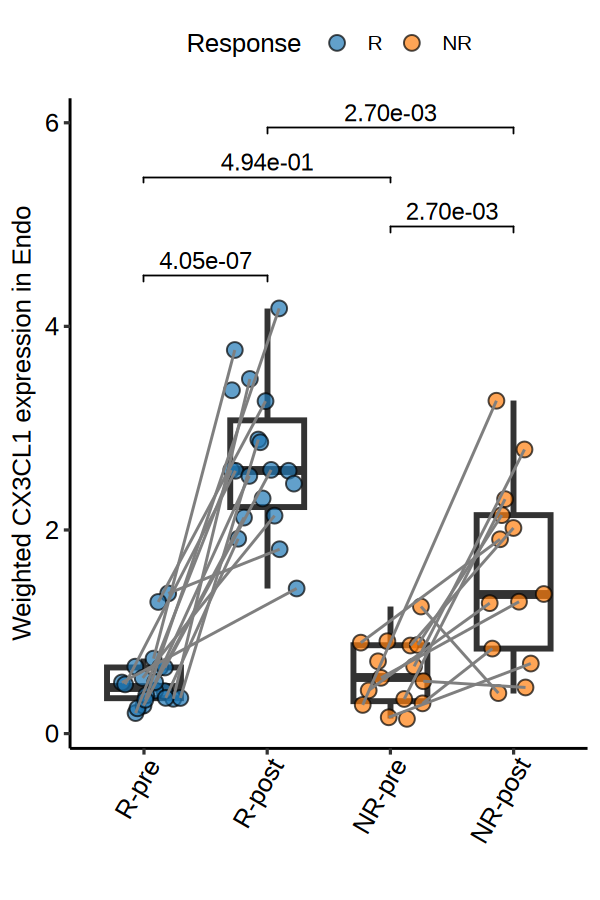

In [15]:
p <- df %>%
    filter(.data[[gp]] %in% gp_lvls[[gp]]) %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'logcpm', pt_fill = gp, xangle = 60,
                      xorder = comb_order, fill_order = gp_lvls[[gp]], facet_by = NULL) +
    labs(y = 'Weighted CX3CL1 expression in Endo', fill = 'Response')
p <- add_bh_wilcox(
    plot = p,
    comparisons = gp_comp_map[[gp]],
    x = 'plot_x', y = 'logcpm', facet_by = NULL,
    stats_file = str_glue('{outdir}/figs8e1-weighted_CX3CL1-wilcoxon_bh.tsv')
)
ggsave(filename = str_glue('{outdir}/figs8e1-box_pbulk_exprs-weighted_CX3CL1_in_endo.pdf'),
       plot = p, width = 4, height = 6)
jp_opt(wd = 4, hg = 6)
print(p)


### expression in sample: s8e-2

In [16]:
f_exprs <- '../../data/stage4/a04_cx3cl1/tme_exprs/cx3cl1_tme_exprs.tsv'

In [17]:
# add clin info
df <- read_tsv(f_exprs, show_col_types = F) %>%
    separate(col = 'sample', into = c('patient', 'sample_type'), sep = '-', remove = F) %>% 
    mutate(cx3cl1_exprs_log = log1p(cx3cl1_exprs_unlog)) %>% 
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))

df %>% write_tsv(str_glue('{outdir}/figs8e2-pbulk_exprs-cx3cl1_in_TME.tsv'))

2026-07-18 18:12:32.528883 INFO::these clinial info will be added: response


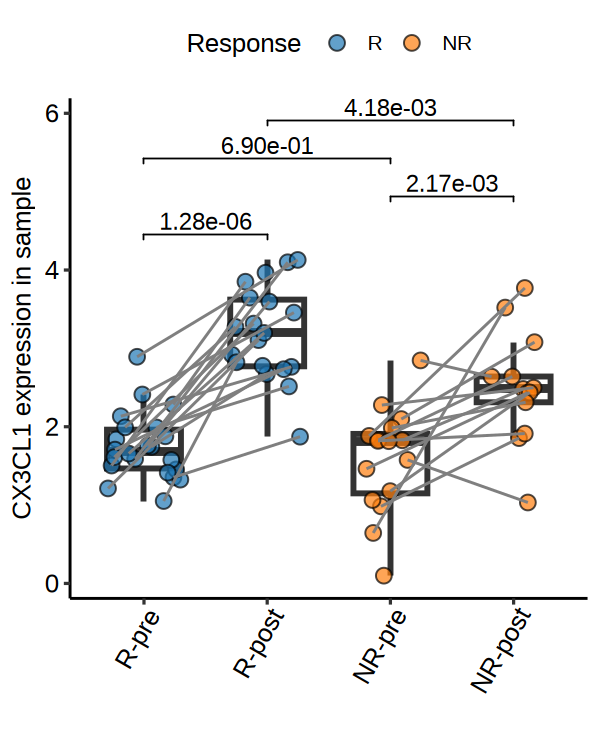

In [18]:
p <- read_tsv(str_glue('{outdir}/figs8e2-pbulk_exprs-cx3cl1_in_TME.tsv'), show_col_types = F) %>% 
    filter(!is.na(.data[[gp]])) %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'cx3cl1_exprs_log', pt_fill = gp, facet_by = NULL,
                      xorder = comb_order, fill_order = gp_lvls[[gp]], xangle = 60) + 
    labs(y = 'CX3CL1 expression in sample', fill = 'Response')
p <- add_bh_wilcox(
    plot = p,
    comparisons = gp_comp_map[[gp]],
    x = 'plot_x', y = 'cx3cl1_exprs_log', facet_by = NULL,
    stats_file = str_glue('{outdir}/figs8e2-CX3CL1_TME-wilcoxon_bh.tsv')
)
ggsave(filename = str_glue('{outdir}/figs8e2-box_exprs-cx3cl1_pbulk_in_TME.pdf'), plot = p, height = 5, width = 4)
jp_opt(wd = 4, hg = 5)
print(p)


### s8f: weight expression vs CD8_CX3CR1 shannon index

In [19]:
f_data <- '../../data/stage4/a04_cx3cl1/endo_wt_cx3cl1_exprs_min50/cx3cl1_weighted_exprs_vs_t_diversity.tsv'

In [20]:
df <- read_tsv(f_data, show_col_types = F) %>% 
    mutate(wt_cx3cl1_exprs_log1p = log1p(wt_cx3cl1_exprs_unlog)) %>%
    filter(subtype == 'CD8_CX3CR1') %>% 
    select(sample, patient, sample_type, wt_cx3cl1_exprs_log1p, cd8_cx3cr1_shannon = shannon) %>% 
    add_clin_info(f_pat_gp, columns = gp, merge_by = 'patient') %>% 
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))
df %>% write_tsv(str_glue('{outdir}/figs8f-weighted_CX3CL1_exprs-CD8_CX3CR1_diversity.tsv'))

2026-07-18 18:12:41.529197 INFO::these clinial info will be added: response


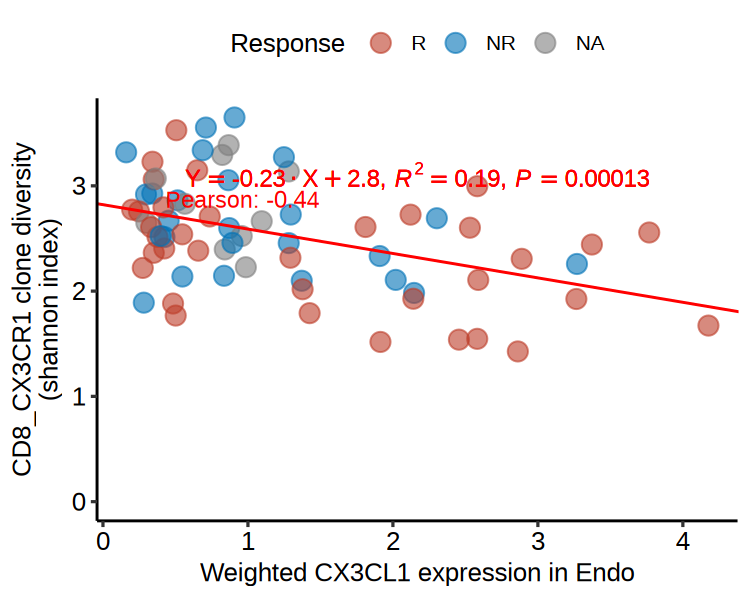

In [21]:
p <- df %>%
    mutate(color_by = factor(.data[[gp]], gp_lvls[[gp]])) %>%
    scatter_with_fit(x = 'wt_cx3cl1_exprs_log1p', y = 'cd8_cx3cr1_shannon', color = 'color_by') +
    scale_color_nejm(na.value = 'gray50') +
    ylim(0, NA) +
    labs(x = 'Weighted CX3CL1 expression in Endo',
         y = 'CD8_CX3CR1 clone diversity\n(shannon index)',
         color = 'Response')
ggsave(filename = str_glue('{outdir}/figs8f-scatter_corr-weighted_CX3CL1_exprs-CD8_CX3CR1_diversity.pdf'),
       plot = p, width = 5, height = 4)
jp_opt(wd = 5, hg = 4)
print(p)


### s8g: CD8_CX3CR1 expanded pct in T+NK group by weight CX3CL1 exprs in endo

In [22]:
f_data <- '../../data/stage4/a04_cx3cl1/endo_wt_cx3cl1_exprs/cx3cl1_weighted_exprs_vs_clonoExpand.tsv'

In [23]:
df <- read_tsv(file = f_data, show_col_types = F) %>% 
    mutate(wt_cx3cl1_exprs_log1p = log1p(wt_cx3cl1_exprs_unlog)) %>%
    filter(subtype == 'CD8_CX3CR1') %>% 
    select(sample, patient, wt_cx3cl1_exprs_log1p, cd8_cx3cr1_expand_pct_in_TNK = expand_pct_in_TNK) %>% 
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient')
df %>% write_tsv(str_glue('{outdir}/figs8g-weighted_CX3CL1_exprs-CD8_CX3CR1_expand_pct_in_TNK.tsv'))

2026-07-18 18:12:47.212217 INFO::these clinial info will be added: response


2026-07-18 18:18:44.264154 INFO::expression cutoff: 0.840079


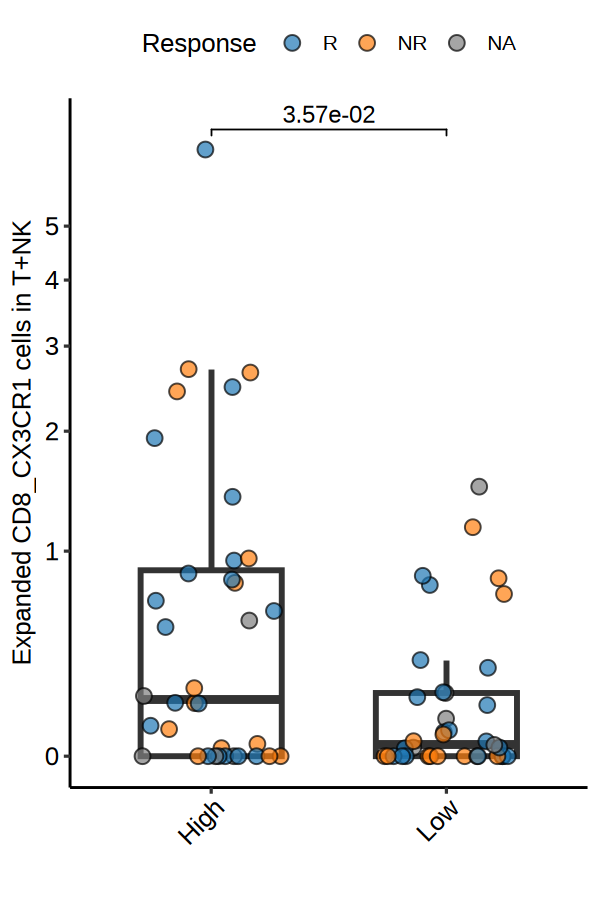

In [6]:
cutoff <- quantile(df$wt_cx3cl1_exprs_log1p, 0.5)
loginfo('expression cutoff: %g', cutoff)
p <- df %>% 
    mutate(exprs_type = if_else(wt_cx3cl1_exprs_log1p <= cutoff, 'Low', 'High'),
           color_by = factor(.data[[gp]], gp_lvls[[gp]])) %>% 
    cell_comp_boxplot(x = 'exprs_type',
                      y = 'cd8_cx3cr1_expand_pct_in_TNK', 
                      pt_fill = 'color_by',
                      facet_by = NULL, pair_by = NULL,
                      xorder = NULL, fill_order = gp_lvls[[gp]]) +
    scale_y_continuous(trans=lognp_trans(n = 1),
                       breaks = c(0, seq(1, 5, 1), 10)) +
    labs(y = 'Expanded CD8_CX3CR1 cells in T+NK', fill = 'Response')
p <- add_bh_wilcox(
    plot = p,
    comparisons = list(c('High', 'Low')),
    x = 'plot_x', y = 'cd8_cx3cr1_expand_pct_in_TNK', facet_by = NULL,
    stats_file = str_glue('{outdir}/figs8g-expand_by_CX3CL1-wilcoxon_bh.tsv'),
    annotation_y_transform = function(z) log10(z + 1)
)
ggsave(filename = str_glue('{outdir}/figs8g-CD8_CX3CR1_expand_pct_in_TNK-by_wt_cx3cl1_exprs_median.pdf'),
       plot = p, width = 4, height = 6)
jp_opt(wd = 4, hg = 6)
print(p)


### s8h: endo cell composition

only 3 samples with <= 50 endo cells (min 34), thus not filter by cell count

In [25]:
f_cc <- '../../data/stage4/a02_cc/composition/endo_cell_comp.csv'
valid_ctypes <- c('Endo_ACKR1', 'Endo_CCL21')

In [26]:
df <- read_csv(f_cc, show_col_types = F) %>%
    filter(cell_type %in% valid_ctypes) %>%
    select(sample, patient, sample_type, cell_type, pct) %>%
    add_clin_info(ftsv = f_pat_gp, columns = gp, merge_by = 'patient') %>%
    mutate(sample_type = case_match(sample_type, 'Baseline' ~ 'pre', 'Treat' ~ 'post'))

df %>% write_tsv(str_glue('{outdir}/figs8h-cc_endo.tsv'))

2026-07-18 18:13:16.077348 INFO::these clinial info will be added: response


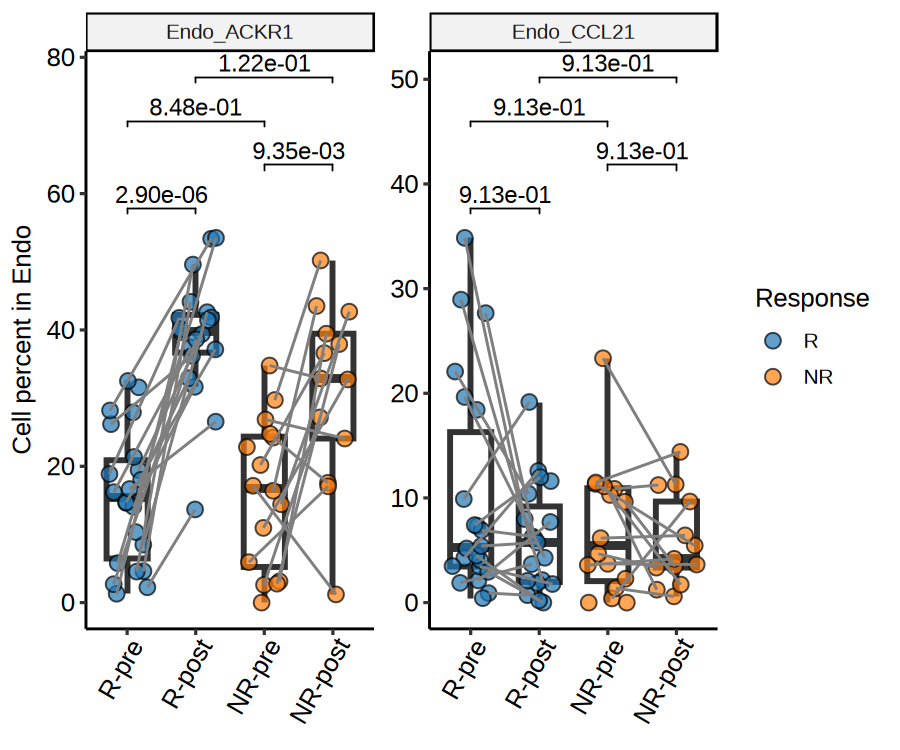

In [27]:
p <- df %>% 
    filter(.data[[gp]] %in% gp_lvls[[gp]]) %>%
    cell_comp_boxplot(x = c(gp, 'sample_type'), y = 'pct', pt_fill = gp, xangle = 60,
                      xorder = comb_order, fill_order = gp_lvls[[gp]]) +
    labs(y = 'Cell percent in Endo', fill = 'Response') +
    theme(axis.title.x = element_blank(), legend.position = 'right')
p <- add_bh_wilcox(
    plot = p,
    comparisons = gp_comp_map[[gp]],
    x = 'plot_x', y = 'pct', facet_by = 'cell_type',
    stats_file = str_glue('{outdir}/figs8h-endo_composition-wilcoxon_bh.tsv')
)
ggsave(filename = str_glue('{outdir}/figs8h-box_cc-endo.pdf'), plot = p, width = 6, height = 5)
jp_opt(wd = 6, hg = 5)
print(p)
